# Root Time √
### The most-used formula in finance, and the assumption nobody checks

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

Daily volatility times √252 is annual volatility. One-day VaR times √10 is the regulator's
ten-day VaR. It is on every fact sheet and in every risk system, and it is exactly right only
if today's return tells you nothing about tomorrow's. This notebook measures how untrue that is,
and what the untruth costs.

> \U0001F4D3 **This is the plain-language layer.** Variance ratios, robust test statistics and
> the closed-form validation are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Is √T right for the S&P? | Very nearly. Which is why nobody questions it. |
| Is it right for a bond fund? | No. Their returns are strongly autocorrelated and the rule understates the long-horizon risk. |
| Does the error reach the risk report? | Yes — a 10-day VaR built by the √10 rule inherits it directly. |
| Is the error random? | No. Wherever it is large, it points the same way: the book looks calmer than it is. |

## 1 · The claim

> *"Volatility scales with the square root of time."*

It is not a claim about markets; it is a theorem about **independent** random variables. The
variance of a sum of independent things is the sum of their variances, so standard deviation
grows like √T. Everything hinges on the word *independent*.

## 2 · So what?

The rule sits underneath the annualised volatility on every fact sheet, the 10-day VaR in every
bank's regulatory return, the Sharpe ratio in every pitch deck, and the position sizing in most
systematic strategies. If it is wrong by 20% somewhere, that 20% propagates everywhere.

In [2]:
from sqrt_time import data, strategy as st

px = data.load_prices()
rets = {tk: px[tk].dropna().pct_change().dropna() for tk in data.TICKERS}
print(f"as-of {data.AS_OF}")
for tk, r in rets.items():
    print(f"  {tk:8s} n={len(r):6,}  daily vol {r.std():.4f}  "
          f"annualised (sqrt rule) {r.std() * np.sqrt(252):6.2%}  AR(1) {r.autocorr(1):+.3f}")

as-of 2026-06-30
  SPY      n= 8,410  daily vol 0.0117  annualised (sqrt rule) 18.58%  AR(1) -0.082
  QQQ      n= 6,868  daily vol 0.0170  annualised (sqrt rule) 26.95%  AR(1) -0.058
  IWM      n= 6,560  daily vol 0.0151  annualised (sqrt rule) 23.90%  AR(1) -0.068
  EEM      n= 5,839  daily vol 0.0171  annualised (sqrt rule) 27.12%  AR(1) -0.111
  TLT      n= 6,017  daily vol 0.0090  annualised (sqrt rule) 14.30%  AR(1) -0.029
  IEF      n= 6,017  daily vol 0.0043  annualised (sqrt rule)  6.81%  AR(1) -0.029
  SHY      n= 6,017  daily vol 0.0010  annualised (sqrt rule)  1.52%  AR(1) -0.073
  GLD      n= 5,435  daily vol 0.0115  annualised (sqrt rule) 18.18%  AR(1) -0.013
  TQQQ     n= 4,119  daily vol 0.0385  annualised (sqrt rule) 61.15%  AR(1) -0.077
  BTC-USD  n= 4,304  daily vol 0.0348  annualised (sqrt rule) 55.31%  AR(1) -0.023


Look at the AR(1) column. SPY is ~0. SHY — a short-Treasury fund — is not remotely 0. Those two
assets sit in the same risk report, scaled by the same formula.

## 3 · How would we even know?

Two ways, and we do both. The clever way is a **variance ratio**: compare the variance of
21-day returns with 21 times the variance of daily returns. The blunt way is to chop the tape
into non-overlapping blocks and just measure. If they agree, there is nothing left to argue
about.

## 4 · The teardown

### 4.1 The variance-ratio curve, tape by tape

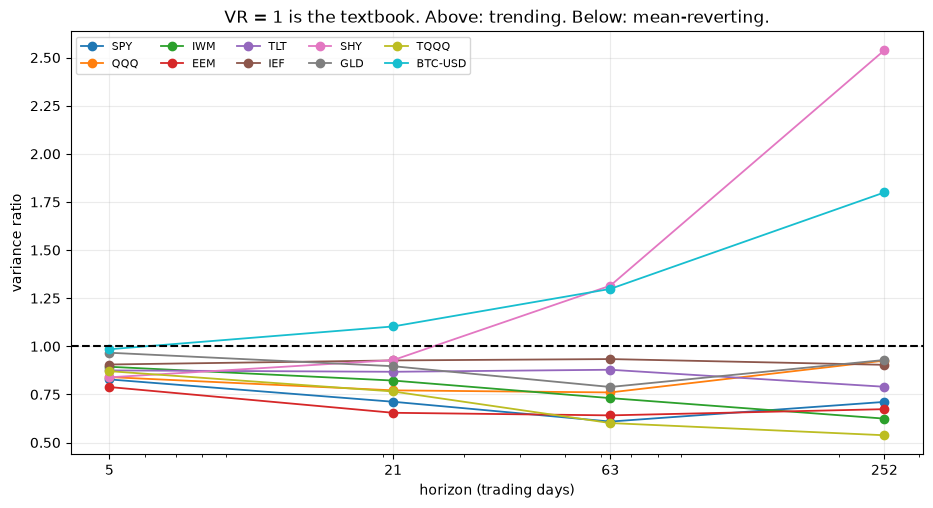

q,5,21,63,252
SPY,0.8300,0.7100,0.6100,0.7100
QQQ,0.8400,0.7700,0.7600,0.9300
IWM,0.8900,0.8200,0.7300,0.6200
EEM,0.7900,0.6500,0.6400,0.6700
TLT,0.8700,0.8700,0.8800,0.7900
IEF,0.9100,0.9300,0.9300,0.9000
SHY,0.8400,0.9300,1.3200,2.5400
GLD,0.9700,0.9000,0.7900,0.9300
TQQQ,0.8700,0.7700,0.6000,0.5400
BTC-USD,0.9800,1.1000,1.3000,1.8000


In [3]:
curves = {tk: st.vr_curve(r) for tk, r in rets.items()}
fig, ax = plt.subplots(figsize=(11, 5.5))
for tk, c in curves.items():
    ax.plot(c.index, c["vr"], marker="o", lw=1.3, label=tk)
ax.axhline(1.0, color="k", lw=1.5, ls="--")
ax.set_xscale("log"); ax.set_xticks(list(st.HORIZONS))
ax.set_xticklabels([str(q) for q in st.HORIZONS])
ax.set_xlabel("horizon (trading days)"); ax.set_ylabel("variance ratio")
ax.set_title("VR = 1 is the textbook. Above: trending. Below: mean-reverting.")
ax.legend(ncol=5, fontsize=8)
plt.show()
pd.DataFrame({tk: c["vr"] for tk, c in curves.items()}).T.round(2)

> \U0001F52C **For the quants.** The equity indices hug 1.0 across every horizon. The bond and
> bill funds sit above it. That is not a market inefficiency — it is the yield process being
> persistent, plus a dose of stale pricing.

### 4.2 The blunt check

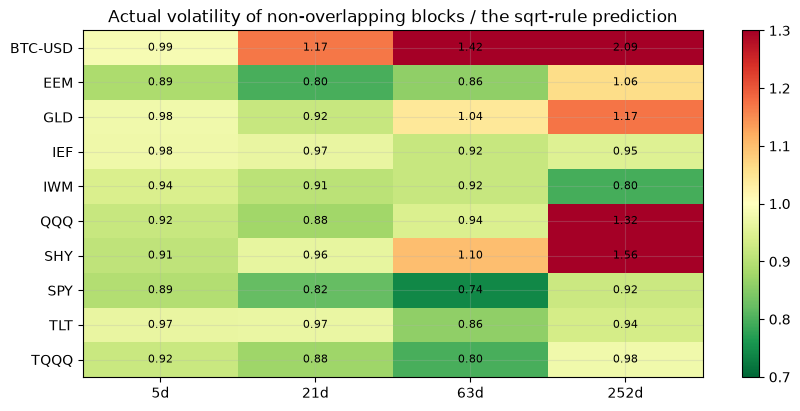

In [4]:
rows = []
for tk in data.TICKERS:
    rs = st.realised_scaling(px[tk].dropna())
    for q, r in rs.iterrows():
        rows.append({"ticker": tk, "q": q, "ratio": r["ratio"], "blocks": r["n_blocks"]})
d = pd.DataFrame(rows).pivot(index="ticker", columns="q", values="ratio")
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(d.values, cmap="RdYlGn_r", vmin=0.7, vmax=1.3, aspect="auto")
ax.set_xticks(range(d.shape[1])); ax.set_xticklabels([f"{q}d" for q in d.columns])
ax.set_yticks(range(d.shape[0])); ax.set_yticklabels(d.index)
for i in range(d.shape[0]):
    for j in range(d.shape[1]):
        if np.isfinite(d.values[i, j]):
            ax.text(j, i, f"{d.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Actual volatility of non-overlapping blocks / the sqrt-rule prediction")
fig.colorbar(im, ax=ax)
plt.show()

### 4.3 What it costs where it matters

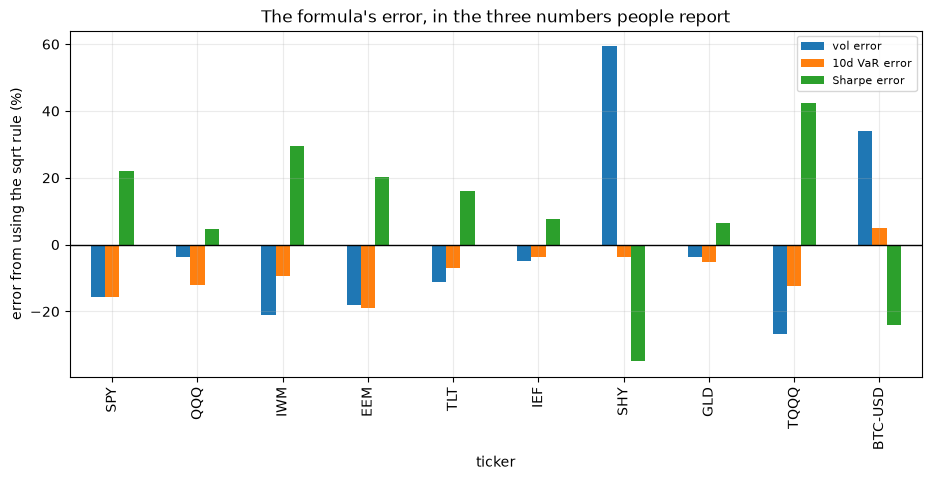

,vol error,10d VaR error,Sharpe error
ticker,,,
SPY,-15.7000,-15.6000,22.0000
QQQ,-3.8000,-12.2000,4.7000
IWM,-21.0000,-9.3000,29.5000
EEM,-17.9000,-19.1000,20.3000
TLT,-11.1000,-6.9000,15.9000
IEF,-4.9000,-3.7000,7.7000
SHY,59.3000,-3.7000,-35.0000
GLD,-3.6000,-5.3000,6.4000
TQQQ,-26.7000,-12.5000,42.5000


In [5]:
rows = []
for tk, r in rets.items():
    vr_a = curves[tk].loc[252, "vr"]
    vr_21 = curves[tk].loc[21, "vr"]
    ve = st.vol_scaling_error(vr_a)
    var_e = st.var_scaling_error(float(r.std(ddof=1)), vr_21)["error_pct"]
    sh = st.sharpe_scaling_error(r)
    rows.append({"ticker": tk, "vol error": ve, "10d VaR error": var_e,
                 "Sharpe error": sh["relative_error"]})
d = pd.DataFrame(rows).set_index("ticker")
fig, ax = plt.subplots(figsize=(11, 4.5))
(d * 100).plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("error from using the sqrt rule (%)")
ax.set_title("The formula's error, in the three numbers people report")
ax.legend(title="", fontsize=8)
plt.show()
(d * 100).round(1)

## 5 · The verdict

**Signal: Weak.** Yes, and not subtly. At the annual horizon **2 of 10** tapes reject VR = 1 with a heteroskedasticity-robust |z| >= 2. The extremes are **SHY** at VR = **2.54** (trending: sqrt(T) *understates* its annual volatility by 59%) and **TQQQ** at VR = **0.54** (mean-reverting: it *overstates* by 27%). Equity indices sit close to 1, which is why the rule survived: it is nearly right for the one asset class everybody tests it on.

**Usefulness: Useful.** On a 10-day 99% VaR — the Basel horizon, computed by exactly this rule — the correction reaches **-19%** on EEM. An annualised Sharpe moves too: Lo's (2002) factor differs from sqrt(252) by up to **+42%** — though that correction carries a 12% standard deviation of its own on i.i.d. data, so the variance ratio, not the Sharpe factor, is the load-bearing number. On SPY the whole correction is -15.7% — invisible, and that is precisely why nobody checks it on anything else.

## 6 · Does it change a decision?

For an equity index: no, and you can keep using the rule with a clear conscience. For anything
with a slow-moving underlying — bond funds, credit, anything whose NAV is priced off a matrix
rather than a trade — the correction is the difference between a limit that binds and one that
does not.

## 7 · Going further \U0001F6AA

- **Jumps** break the rule in the *opposite* direction from mean reversion (Danielsson &
  Zigrand 2006): a fat-tailed tape can need *more* than √T even with zero autocorrelation.
- **Stale pricing** (Getmansky, Lo & Makarov 2004) manufactures autocorrelation out of nothing
  — the hedge-fund version of the bond-fund result above.
- **Intraday scaling**: the same question inside the day, where the U-shaped volume pattern
  makes √t fail before lunch.